This final notebook will answer the last part of the research:

> **Can the selected model operate efficiently enough for real-time facial emotion recognition?**

We'll measure:

model parameters → model size → GPU latency → CPU latency → FPS → final model comparison → export model → webcam implementation

#Setup

In [1]:
import os
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torchvision.models import resnet50

from google.colab import drive

drive.mount(
    "/content/drive"
)

BASE_DIR = (
    "/content/drive/MyDrive/"
    "Emotion_Recognition_Thesis"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "results"
)

REALTIME_DIR = os.path.join(
    RESULT_DIR,
    "realtime"
)

os.makedirs(
    REALTIME_DIR,
    exist_ok=True
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


#Load final model

In [2]:
EMOTION_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = 8

model = resnet50(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

checkpoint_path = os.path.join(
    MODEL_DIR,
    "resnet50_weighted_best.pth"
)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Final weighted ResNet50 loaded.")

Final weighted ResNet50 loaded.


#Count parameters

In [3]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 23,524,424
Trainable parameters: 23,524,424


#Check checkpoint size

In [4]:
model_size_mb = (
    os.path.getsize(
        checkpoint_path
    )
    / (1024 ** 2)
)

print(
    f"Checkpoint size: "
    f"{model_size_mb:.2f} MB"
)

Checkpoint size: 90.05 MB


#GPU inference latency

In [5]:
dummy_input = torch.randn(
    1,
    3,
    224,
    224
).to(device)

In [6]:
with torch.no_grad():

    for _ in range(50):

        _ = model(
            dummy_input
        )

if device.type == "cuda":
    torch.cuda.synchronize()

print("Warm-up complete.")

Warm-up complete.


In [7]:
gpu_times = []

with torch.no_grad():

    for _ in range(300):

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        _ = model(
            dummy_input
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()

        gpu_times.append(
            (end - start) * 1000
        )

In [8]:
gpu_mean_latency = np.mean(
    gpu_times
)

gpu_median_latency = np.median(
    gpu_times
)

gpu_std_latency = np.std(
    gpu_times
)

gpu_fps = (
    1000 /
    gpu_mean_latency
)

print(
    f"Mean GPU latency: "
    f"{gpu_mean_latency:.2f} ms"
)

print(
    f"Median GPU latency: "
    f"{gpu_median_latency:.2f} ms"
)

print(
    f"Std latency: "
    f"{gpu_std_latency:.2f} ms"
)

print(
    f"Theoretical model FPS: "
    f"{gpu_fps:.2f}"
)

Mean GPU latency: 6.15 ms
Median GPU latency: 5.85 ms
Std latency: 1.00 ms
Theoretical model FPS: 162.59


#More robust latency statistics

In [9]:
print(
    f"P50 latency: "
    f"{np.percentile(gpu_times, 50):.2f} ms"
)

print(
    f"P90 latency: "
    f"{np.percentile(gpu_times, 90):.2f} ms"
)

print(
    f"P95 latency: "
    f"{np.percentile(gpu_times, 95):.2f} ms"
)

print(
    f"P99 latency: "
    f"{np.percentile(gpu_times, 99):.2f} ms"
)

P50 latency: 5.85 ms
P90 latency: 6.71 ms
P95 latency: 8.16 ms
P99 latency: 11.33 ms


#CPU benchmark

In [10]:
cpu_model = resnet50(
    weights=None
)

cpu_model.fc = nn.Linear(
    cpu_model.fc.in_features,
    NUM_CLASSES
)

cpu_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location="cpu"
    )
)

cpu_model.eval()

cpu_input = torch.randn(
    1,
    3,
    224,
    224
)

In [11]:
with torch.no_grad():

    for _ in range(20):

        _ = cpu_model(
            cpu_input
        )

In [12]:
cpu_times = []

with torch.no_grad():

    for _ in range(100):

        start = time.perf_counter()

        _ = cpu_model(
            cpu_input
        )

        end = time.perf_counter()

        cpu_times.append(
            (end - start) * 1000
        )

In [13]:
cpu_mean_latency = np.mean(
    cpu_times
)

cpu_median_latency = np.median(
    cpu_times
)

cpu_fps = (
    1000 /
    cpu_mean_latency
)

print(
    f"Mean CPU latency: "
    f"{cpu_mean_latency:.2f} ms"
)

print(
    f"Median CPU latency: "
    f"{cpu_median_latency:.2f} ms"
)

print(
    f"Theoretical CPU FPS: "
    f"{cpu_fps:.2f}"
)

Mean CPU latency: 127.97 ms
Median CPU latency: 117.80 ms
Theoretical CPU FPS: 7.81


# **Final Results**

##Save latency results

In [14]:
latency_results = pd.DataFrame({
    "Device": [
        "NVIDIA T4 GPU",
        "Colab CPU"
    ],

    "Mean_Latency_ms": [
        gpu_mean_latency,
        cpu_mean_latency
    ],

    "Median_Latency_ms": [
        gpu_median_latency,
        cpu_median_latency
    ],

    "Theoretical_Model_FPS": [
        gpu_fps,
        cpu_fps
    ]
})

latency_results

,Device,Mean_Latency_ms,Median_Latency_ms,Theoretical_Model_FPS
0,NVIDIA T4 GPU,6.150450,5.853181,162.589741
1,Colab CPU,127.968811,117.797304,7.814404


In [15]:
gpu_latency_percentiles = pd.DataFrame({
    "Statistic": [
        "P50",
        "P90",
        "P95",
        "P99"
    ],

    "Latency_ms": [
        np.percentile(gpu_times, 50),
        np.percentile(gpu_times, 90),
        np.percentile(gpu_times, 95),
        np.percentile(gpu_times, 99)
    ]
})

gpu_latency_percentiles.to_csv(
    os.path.join(
        REALTIME_DIR,
        "gpu_latency_percentiles.csv"
    ),
    index=False
)

gpu_latency_percentiles

,Statistic,Latency_ms
0,P50,5.853181
1,P90,6.712142
2,P95,8.161276
3,P99,11.327039


##Latency distribution figure

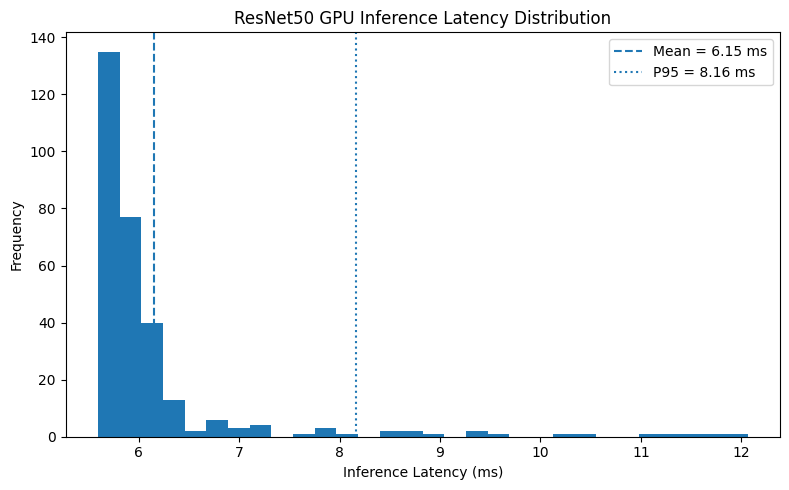

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    gpu_times,
    bins=30
)

ax.axvline(
    gpu_mean_latency,
    linestyle="--",
    label=f"Mean = {gpu_mean_latency:.2f} ms"
)

ax.axvline(
    np.percentile(gpu_times, 95),
    linestyle=":",
    label=f"P95 = {np.percentile(gpu_times, 95):.2f} ms"
)

ax.set_xlabel(
    "Inference Latency (ms)"
)

ax.set_ylabel(
    "Frequency"
)

ax.set_title(
    "ResNet50 GPU Inference Latency Distribution"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        REALTIME_DIR,
        "gpu_latency_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Create final model-performance table

In [17]:
final_results = pd.DataFrame({
    "Experiment": [
        "CNN Baseline",
        "ResNet50 Frozen",
        "ResNet50 Fine-Tuned",
        "EfficientNet-B0 Frozen",
        "EfficientNet-B0 Fine-Tuned",
        "Weighted ResNet50 - AffectNet",
        "Weighted ResNet50 - AffectNet Grayscale",
        "Weighted ResNet50 - FERPlus"
    ],

    "Evaluation_Set": [
        "AffectNet Validation",
        "AffectNet Validation",
        "AffectNet Validation",
        "AffectNet Validation",
        "AffectNet Validation",
        "AffectNet Test",
        "AffectNet Test",
        "FERPlus PrivateTest"
    ],

    "Accuracy": [
        0.4522,
        0.4923,
        0.5950,
        0.4886,
        0.5031,
        0.5942,
        0.4442,
        0.0923
    ],

    "Macro_F1": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        0.5517,
        0.4097,
        0.0725
    ]
})

final_results

,Experiment,Evaluation_Set,Accuracy,Macro_F1
0,CNN Baseline,AffectNet Validation,0.4522,NaN
1,ResNet50 Frozen,AffectNet Validation,0.4923,NaN
2,ResNet50 Fine-Tuned,AffectNet Validation,0.5950,NaN
3,EfficientNet-B0 Frozen,AffectNet Validation,0.4886,NaN
4,EfficientNet-B0 Fine-Tuned,AffectNet Validation,0.5031,NaN
5,Weighted ResNet50 - AffectNet,AffectNet Test,0.5942,0.5517
6,Weighted ResNet50 - AffectNet Grayscale,AffectNet Test,0.4442,0.4097
7,Weighted ResNet50 - FERPlus,FERPlus PrivateTest,0.0923,0.0725


In [18]:
final_results.to_csv(
    os.path.join(
        RESULT_DIR,
        "final_thesis_results.csv"
    ),
    index=False
)

print("Final results table saved.")

Final results table saved.


##Saving deployment summary

In [19]:
deployment_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Parameters",
        "Checkpoint Size (MB)",
        "GPU Mean Latency (ms)",
        "GPU Median Latency (ms)",
        "GPU P95 Latency (ms)",
        "GPU Model FPS",
        "CPU Mean Latency (ms)",
        "CPU Model FPS"
    ],

    "Value": [
        "Weighted Fine-Tuned ResNet50",
        total_parameters,
        round(model_size_mb, 2),
        round(gpu_mean_latency, 2),
        round(gpu_median_latency, 2),
        round(
            np.percentile(
                gpu_times,
                95
            ),
            2
        ),
        round(gpu_fps, 2),
        round(cpu_mean_latency, 2),
        round(cpu_fps, 2)
    ]
})

deployment_summary

,Metric,Value
0,Model,Weighted Fine-Tuned ResNet50
1,Parameters,23524424
2,Checkpoint Size (MB),90.05
3,GPU Mean Latency (ms),6.15
4,GPU Median Latency (ms),5.85
5,GPU P95 Latency (ms),8.16
6,GPU Model FPS,162.59
7,CPU Mean Latency (ms),127.97
8,CPU Model FPS,7.81


In [20]:
deployment_summary.to_csv(
    os.path.join(
        REALTIME_DIR,
        "deployment_summary.csv"
    ),
    index=False
)

##Export final model

In [21]:
export_model = resnet50(
    weights=None
)

export_model.fc = nn.Linear(
    export_model.fc.in_features,
    NUM_CLASSES
)

export_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location="cpu"
    )
)

export_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [22]:
example_input = torch.randn(
    1,
    3,
    224,
    224
)

traced_model = torch.jit.trace(
    export_model,
    example_input
)

In [23]:
TORCHSCRIPT_PATH = os.path.join(
    MODEL_DIR,
    "emotion_resnet50_weighted_traced.pt"
)

traced_model.save(
    TORCHSCRIPT_PATH
)

print(
    "TorchScript model saved to:"
)

print(
    TORCHSCRIPT_PATH
)

TorchScript model saved to:
/content/drive/MyDrive/Emotion_Recognition_Thesis/models/emotion_resnet50_weighted_traced.pt


In [24]:
loaded_script_model = torch.jit.load(
    TORCHSCRIPT_PATH,
    map_location="cpu"
)

loaded_script_model.eval()

with torch.no_grad():
    output = loaded_script_model(
        example_input
    )

print(
    "Output shape:",
    output.shape
)

Output shape: torch.Size([1, 8])


##Optional prediction-consistency check

In [25]:
with torch.no_grad():

    original_output = export_model(
        example_input
    )

    traced_output = loaded_script_model(
        example_input
    )

difference = (
    original_output
    -
    traced_output
).abs().max().item()

print(
    "Maximum output difference:",
    difference
)

Maximum output difference: 0.0
